In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

In [5]:
# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
df = pd.read_csv("/content/IMDb Movies India.csv", encoding="latin1")
print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
display()

Raw dataset: 15,509 rows × 10 cols


In [10]:
# ─────────────────────────────────────────────
# 2. CLEAN
# ─────────────────────────────────────────────
# Year: "(2019)" → 2019
df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(float)

# Duration: "109 min" → 109
df["Duration"] = df["Duration"].astype(str).str.extract(r"(\d+)").astype(float)

# Votes: ensure numeric
# Remove commas from the 'Votes' column before converting to numeric
df["Votes"] = df["Votes"].astype(str).str.replace(",", "", regex=False)
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

# Drop rows without a target
df = df.dropna(subset=["Rating"])
print(f"After dropping missing Rating rows: {df.shape[0]:,} rows")

# Fill string NAs with 'Unknown'
for col in ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]:
    df.loc[:, col] = df[col].fillna("Unknown").str.strip()

After dropping missing Rating rows: 7,919 rows


In [12]:
# ─────────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────────

# --- Genre features ---
# Primary genre (first one listed)
df["Primary_Genre"] = df["Genre"].apply(
    lambda x: x.split(",")[0].strip() if pd.notna(x) else "Unknown"
)
# Number of genres
df["Num_Genres"] = df["Genre"].apply(
    lambda x: len(x.split(",")) if pd.notna(x) else 0
)

# --- Log Votes (highly skewed) ---
df["Log_Votes"] = np.log1p(df["Votes"].fillna(0))

# --- Director / Actor frequency encoding ---
# High-frequency → more data → generally stronger signal
for col in ["Director", "Actor 1"]:
    freq = df[col].value_counts()
    df[f"{col}_Count"] = df[col].map(freq)
    # Mean rating by person
    mean_rating = df.groupby(col)["Rating"].transform("mean")
    df[f"{col}_MeanRating"] = mean_rating

# --- Movie age ---
df["Movie_Age"] = 2024 - df["Year"].fillna(df["Year"].median())
display()

In [13]:
# ─────────────────────────────────────────────
# 4. ENCODE CATEGORICALS
# ─────────────────────────────────────────────
le = LabelEncoder()
df["Primary_Genre_Enc"] = le.fit_transform(df["Primary_Genre"].astype(str))

FEATURES = [
    "Year",
    "Duration",
    "Log_Votes",
    "Num_Genres",
    "Primary_Genre_Enc",
    "Movie_Age",
    "Director_Count",
    "Director_MeanRating",
    "Actor 1_Count",
    "Actor 1_MeanRating",
]

TARGET = "Rating"

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Impute remaining NaNs with median
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
X_imp = pd.DataFrame(X_imp, columns=FEATURES)

print(f"\nFinal feature matrix: {X_imp.shape}")


Final feature matrix: (7919, 10)


In [14]:
# ─────────────────────────────────────────────
# 5. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 6,335  |  Test: 1,584


In [15]:
# ─────────────────────────────────────────────
# 6. MODELS
# ─────────────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=150, max_depth=10,
                                               random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                   learning_rate=0.08,
                                                   random_state=42),
}

results = {}
print("\n{'─'*55}")
print(f"{'Model':<25} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("─" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    results[name] = {
        "model": model,
        "preds": preds,
        "RMSE": rmse,
        "MAE":  mae,
        "R2":   r2,
    }
    print(f"{name:<25} {rmse:>7.4f} {mae:>7.4f} {r2:>7.4f}")

print("─" * 55)

# Best model
best_name = min(results, key=lambda k: results[k]["RMSE"])
best      = results[best_name]
print(f"\n★  Best model: {best_name}  (RMSE = {best['RMSE']:.4f})")

# Feature importance (tree-based)
best_model = best["model"]
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
else:
    fi = None


{'─'*55}
Model                        RMSE     MAE      R²
───────────────────────────────────────────────────────
Linear Regression          0.7440  0.5438  0.7022
Ridge Regression           0.7440  0.5438  0.7022
Random Forest              0.6853  0.4501  0.7474
Gradient Boosting          0.6621  0.4430  0.7642
───────────────────────────────────────────────────────

★  Best model: Gradient Boosting  (RMSE = 0.6621)


/tmp/ipykernel_2241/2074827190.py:126: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.savefig("/mnt/user-data/outputs/movie_rating_prediction.png",



Figure saved → movie_rating_prediction.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


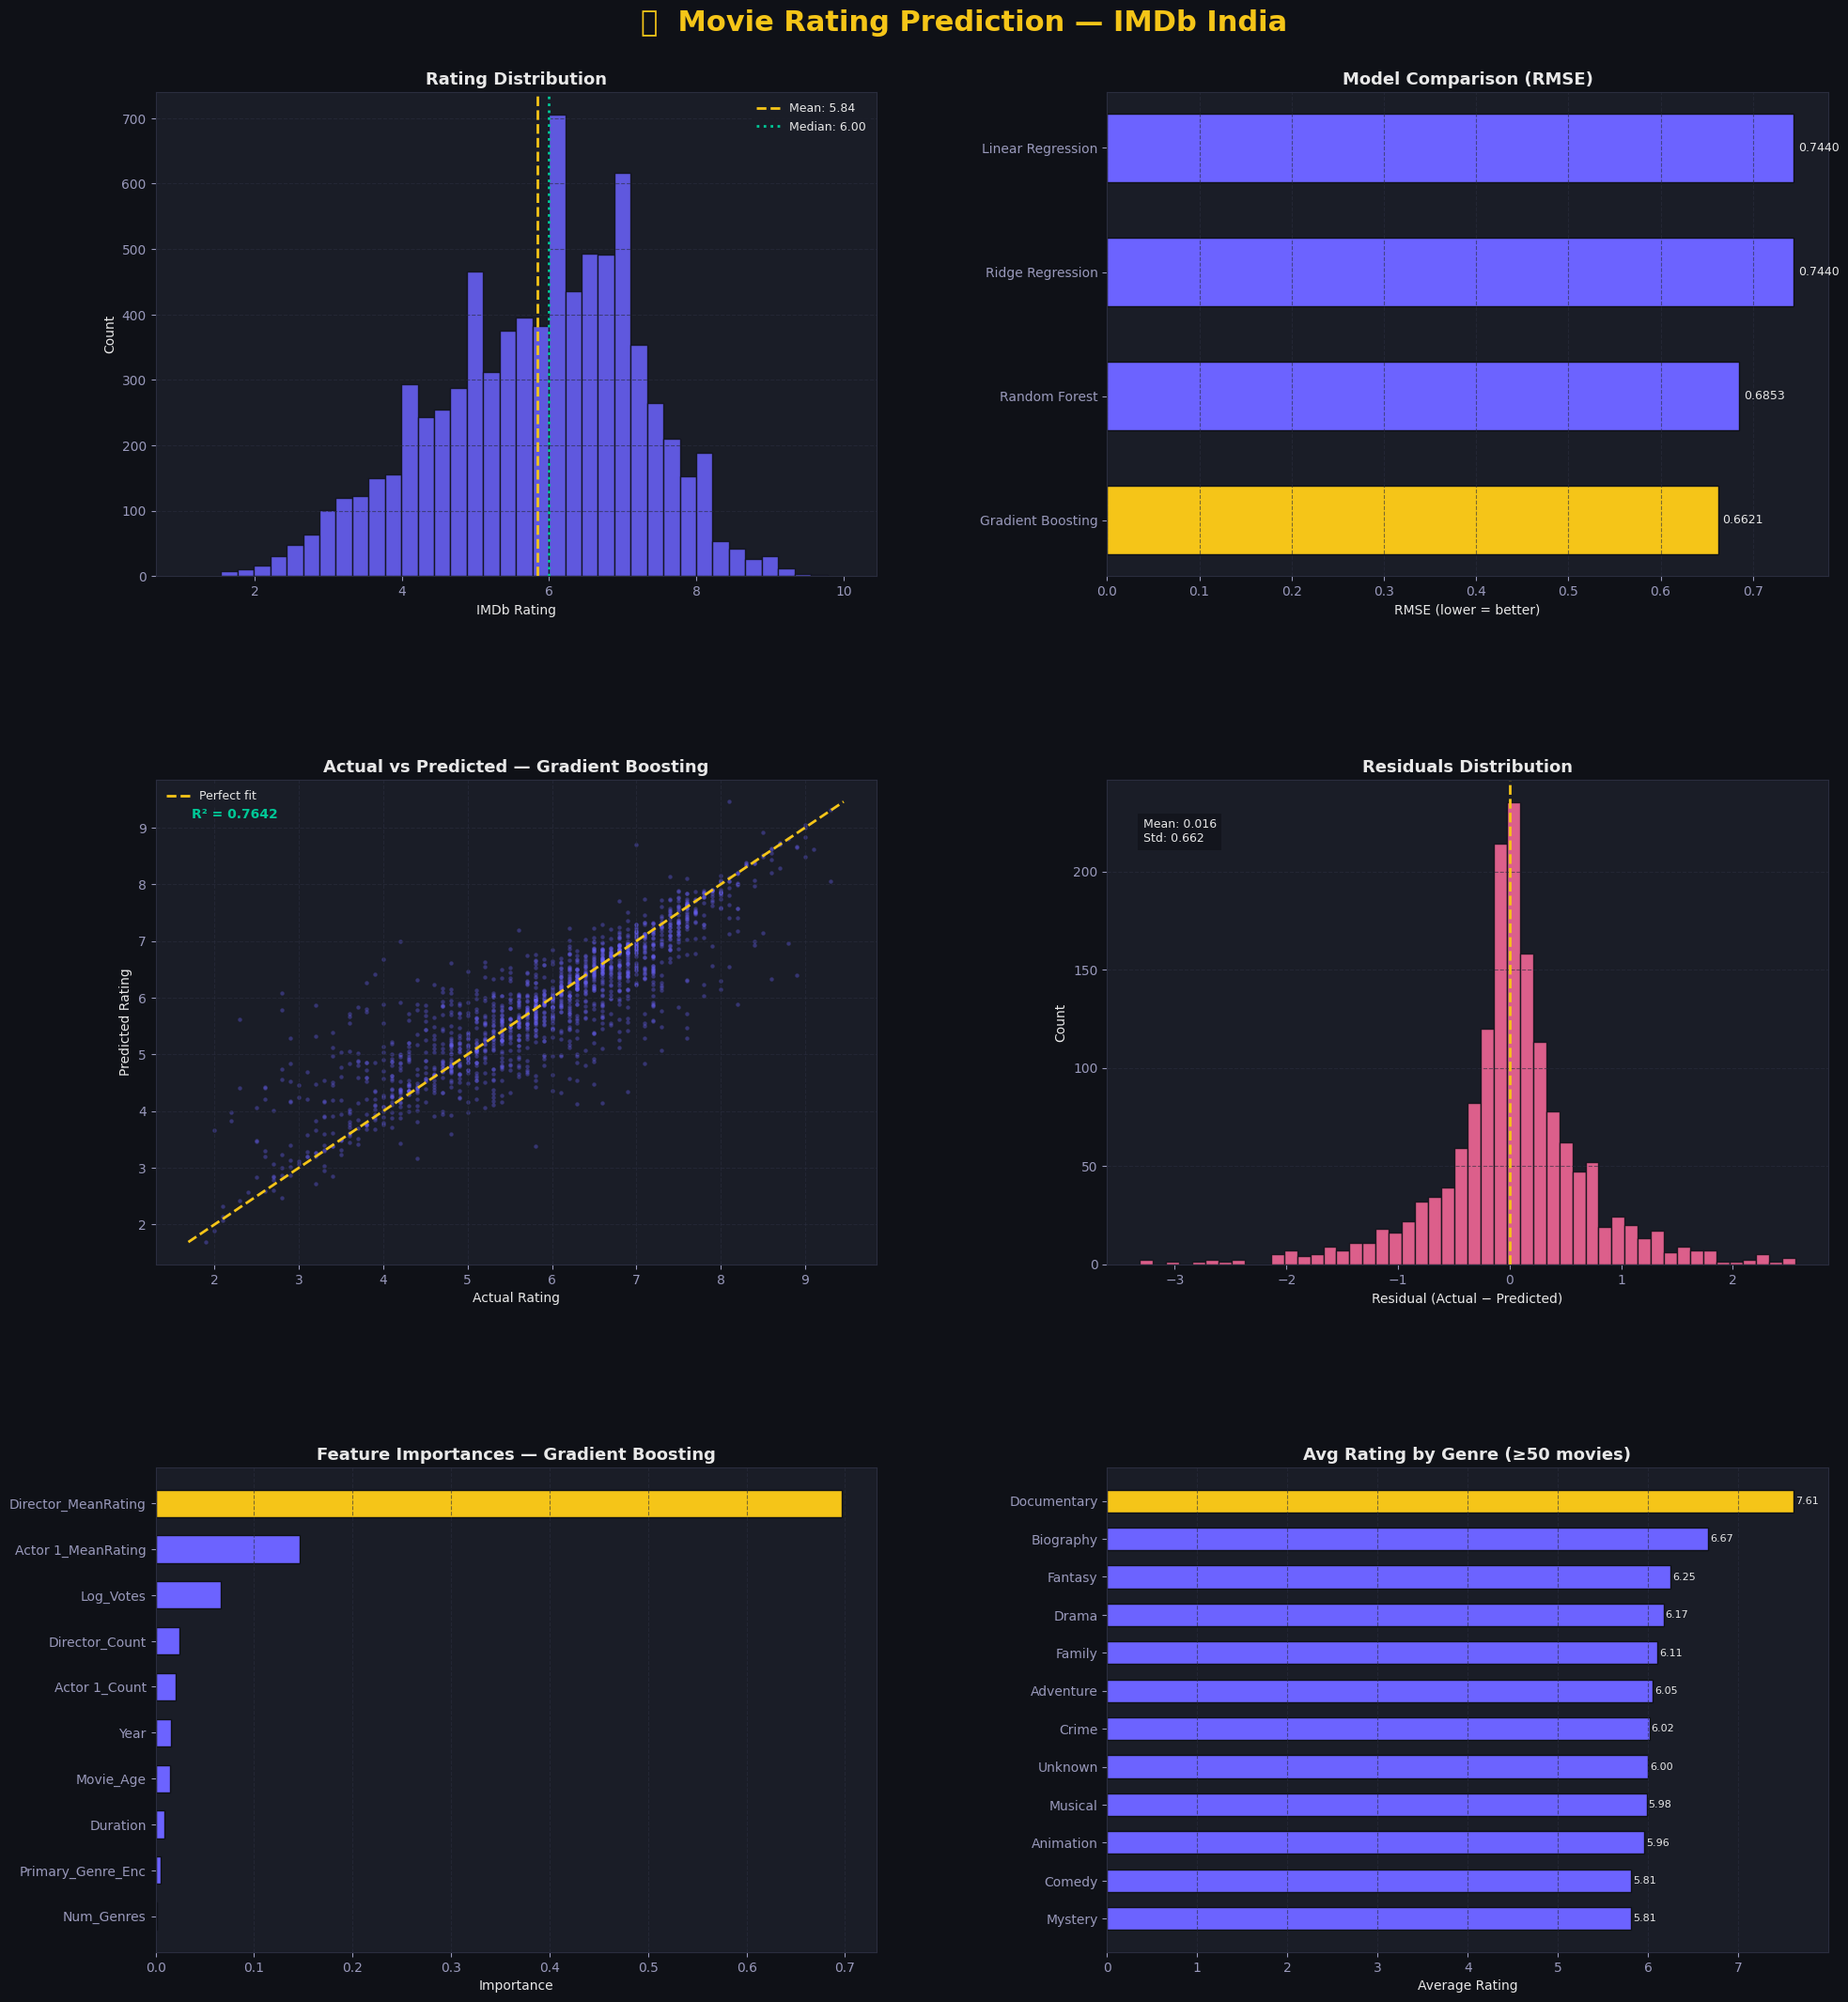

In [17]:
# ─────────────────────────────────────────────
# 7. VISUALISATIONS — single figure, 6 subplots
# ─────────────────────────────────────────────
# Palette
BG      = "#0f1117"
CARD    = "#1a1d27"
ACCENT  = "#6c63ff"
GOLD    = "#f5c518"          # IMDb gold
GREEN   = "#00c897"
PINK    = "#ff6b9d"
TEXT    = "#e8e8e8"
SUBTEXT = "#9999bb"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    CARD,
    "axes.edgecolor":    "#2a2d3e",
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       SUBTEXT,
    "ytick.color":       SUBTEXT,
    "text.color":        TEXT,
    "grid.color":        "#2a2d3e",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
})

fig = plt.figure(figsize=(20, 22), facecolor=BG)
fig.suptitle("🎬  Movie Rating Prediction — IMDb India",
             fontsize=22, fontweight="bold", color=GOLD, y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.42, wspace=0.32,
                       left=0.07, right=0.96,
                       top=0.94, bottom=0.04)

# ── 7.1  Rating distribution ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["Rating"], bins=40, color=ACCENT, edgecolor=BG, alpha=0.85)
ax1.axvline(df["Rating"].mean(), color=GOLD, lw=2, ls="--",
            label=f"Mean: {df['Rating'].mean():.2f}")
ax1.axvline(df["Rating"].median(), color=GREEN, lw=2, ls=":",
            label=f"Median: {df['Rating'].median():.2f}")
ax1.set_title("Rating Distribution", fontsize=13, fontweight="bold")
ax1.set_xlabel("IMDb Rating"); ax1.set_ylabel("Count")
ax1.legend(facecolor=CARD, edgecolor="none", labelcolor=TEXT, fontsize=9)
ax1.grid(True, axis="y")

# ── 7.2  Model comparison bar ─────────────────
ax2 = fig.add_subplot(gs[0, 1])
names  = list(results.keys())
rmses  = [results[n]["RMSE"] for n in names]
colors = [GOLD if n == best_name else ACCENT for n in names]
bars   = ax2.barh(names, rmses, color=colors, edgecolor=BG, height=0.55)
ax2.set_xlabel("RMSE (lower = better)")
ax2.set_title("Model Comparison (RMSE)", fontsize=13, fontweight="bold")
for bar, val in zip(bars, rmses):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9, color=TEXT)
ax2.invert_yaxis()
ax2.grid(True, axis="x")

# ── 7.3  Actual vs Predicted (best model) ─────
ax3 = fig.add_subplot(gs[1, 0])
preds = best["preds"]
ax3.scatter(y_test, preds, alpha=0.35, s=10, color=ACCENT, linewidths=0)
lo, hi = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
ax3.plot([lo, hi], [lo, hi], color=GOLD, lw=2, ls="--", label="Perfect fit")
ax3.set_title(f"Actual vs Predicted — {best_name}", fontsize=13, fontweight="bold")
ax3.set_xlabel("Actual Rating"); ax3.set_ylabel("Predicted Rating")
ax3.legend(facecolor=CARD, edgecolor="none", labelcolor=TEXT, fontsize=9)
ax3.text(0.05, 0.92, f"R² = {best['R2']:.4f}",
         transform=ax3.transAxes, color=GREEN, fontsize=10, fontweight="bold")
ax3.grid(True)

# ── 7.4  Residuals histogram ──────────────────
ax4 = fig.add_subplot(gs[1, 1])
residuals = y_test.values - preds
ax4.hist(residuals, bins=50, color=PINK, edgecolor=BG, alpha=0.85)
ax4.axvline(0, color=GOLD, lw=2, ls="--")
ax4.set_title("Residuals Distribution", fontsize=13, fontweight="bold")
ax4.set_xlabel("Residual (Actual − Predicted)"); ax4.set_ylabel("Count")
ax4.text(0.05, 0.92,
         f"Mean: {residuals.mean():.3f}\nStd: {residuals.std():.3f}",
         transform=ax4.transAxes, color=TEXT, fontsize=9,
         va="top", bbox=dict(facecolor=BG, alpha=0.6, edgecolor="none"))
ax4.grid(True, axis="y")

# ── 7.5  Feature importances ──────────────────
ax5 = fig.add_subplot(gs[2, 0])
if fi is not None:
    palette = [GOLD if i == 0 else ACCENT for i in range(len(fi))]
    ax5.barh(fi.index[::-1], fi.values[::-1], color=palette[::-1],
             edgecolor=BG, height=0.6)
    ax5.set_title(f"Feature Importances — {best_name}",
                  fontsize=13, fontweight="bold")
    ax5.set_xlabel("Importance")
    ax5.grid(True, axis="x")
else:
    ax5.text(0.5, 0.5, "Feature importances\nnot available for this model",
             ha="center", va="center", transform=ax5.transAxes, color=SUBTEXT)
    ax5.set_title("Feature Importances", fontsize=13, fontweight="bold")

# ── 7.6  Avg rating by top genres ─────────────
ax6 = fig.add_subplot(gs[2, 1])
top_genres = (
    df.groupby("Primary_Genre")["Rating"]
      .agg(["mean", "count"])
      .query("count >= 50")
      .sort_values("mean", ascending=False)
      .head(12)
)
bar_colors = [GOLD if i == 0 else ACCENT for i in range(len(top_genres))]
ax6.barh(top_genres.index[::-1], top_genres["mean"].values[::-1],
         color=bar_colors[::-1], edgecolor=BG, height=0.6)
ax6.set_title("Avg Rating by Genre (≥50 movies)", fontsize=13, fontweight="bold")
ax6.set_xlabel("Average Rating")
ax6.grid(True, axis="x")
for i, (idx, row) in enumerate(top_genres[::-1].iterrows()):
    ax6.text(row["mean"] + 0.02, i,
             f'{row["mean"]:.2f}', va="center", fontsize=8, color=TEXT)

import os
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)
plt.savefig("/mnt/user-data/outputs/movie_rating_prediction.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
print("\nFigure saved → movie_rating_prediction.png")

In [18]:
# ─────────────────────────────────────────────
# 8. SUMMARY TABLE
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("FINAL MODEL SCORECARD")
print("=" * 55)
print(f"{'Model':<25} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 55)
for name in results:
    r = results[name]
    star = " ★" if name == best_name else ""
    print(f"{name:<25} {r['RMSE']:>7.4f} {r['MAE']:>7.4f} {r['R2']:>7.4f}{star}")
print("=" * 55)
print(f"\nBest → {best_name}")
print(f"  RMSE  : {best['RMSE']:.4f}  (avg prediction error in rating points)")
print(f"  MAE   : {best['MAE']:.4f}")
print(f"  R²    : {best['R2']:.4f}  ({best['R2']*100:.1f}% variance explained)")



FINAL MODEL SCORECARD
Model                        RMSE     MAE      R²
-------------------------------------------------------
Linear Regression          0.7440  0.5438  0.7022
Ridge Regression           0.7440  0.5438  0.7022
Random Forest              0.6853  0.4501  0.7474
Gradient Boosting          0.6621  0.4430  0.7642 ★

Best → Gradient Boosting
  RMSE  : 0.6621  (avg prediction error in rating points)
  MAE   : 0.4430
  R²    : 0.7642  (76.4% variance explained)
